# CIFAR-100 파인튜닝 & DeiT 비교
## 05_train_cifar100_deit.ipynb

**목표**: 소규모 데이터셋에서 ViT 파인튜닝 및 DeiT 증류 효과 검증

**실험 설계**:
- **데이터**: CIFAR-100 (50K 훈련, 10K 테스트)
- **모델**: ViT-Small vs DeiT-Small 비교
- **에폭**: 5회 (빠른 실행을 위한 최소 설정)

**측정 지표**:
- 학습/검증 정확도 곡선
- Confusion Matrix
- 신뢰도 분석 (ECE)

**산출물**:
- `train_curves_v2.png` - 학습 곡선
- `confusion_matrix_v2.png` - 혼동 행렬  
- `reliability_diagram_v2.png` - 신뢰도 다이어그램
- `cifar100_results_v2.csv` - 훈련 결과

**소요시간**: ~30분 (GPU 환경)


In [1]:
# 필수 라이브러리 및 설정
import os
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('..')
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../reports/tables', exist_ok=True)
os.makedirs('../experiments/logs', exist_ok=True)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
import time
from tqdm import tqdm
from typing import Dict, List, Tuple

# 시각화 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# 한글 폰트 설정 (Windows 환경)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
    plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지
    print("✅ 한글 폰트 설정: 맑은 고딕")
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    print("✅ 한글 폰트 설정: AppleGothic")
else:  # Linux
    plt.rcParams['font.family'] = 'DejaVu Sans'
    print("✅ 폰트 설정: DejaVu Sans")

# 랜덤 시드 고정
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 디바이스: {device}")

# 실험 설정 (빠른 실행을 위한 최소 설정)
EPOCHS = 5
BATCH_SIZE = 128
LEARNING_RATE = 1e-4
NUM_CLASSES = 100

print(f"⚙️  실험 설정:")
print(f"   에폭: {EPOCHS}")
print(f"   배치 크기: {BATCH_SIZE}")
print(f"   학습률: {LEARNING_RATE}")
print(f"   클래스 수: {NUM_CLASSES}")


✅ 한글 폰트 설정: 맑은 고딕
🚀 디바이스: cpu
⚙️  실험 설정:
   에폭: 5
   배치 크기: 128
   학습률: 0.0001
   클래스 수: 100


In [2]:
# CIFAR-100 데이터셋 로드 및 전처리
print("📦 CIFAR-100 데이터셋 로드 중...")

# 데이터 증강 및 전처리 정의
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ViT 입력 크기로 조정
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 데이터셋 로드
train_dataset = torchvision.datasets.CIFAR100(
    root='../data', train=True, download=True, transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR100(
    root='../data', train=False, download=True, transform=test_transform
)

# 빠른 실행을 위한 서브셋 (전체 데이터의 20%)
train_size = int(0.2 * len(train_dataset))
test_size = int(0.2 * len(test_dataset))

train_subset = torch.utils.data.Subset(train_dataset, 
                                      torch.randperm(len(train_dataset))[:train_size])
test_subset = torch.utils.data.Subset(test_dataset,
                                     torch.randperm(len(test_dataset))[:test_size])

# 데이터 로더 생성
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, 
                         shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, 
                        shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ 데이터셋 로드 완료:")
print(f"   훈련 샘플: {len(train_subset):,}")
print(f"   테스트 샘플: {len(test_subset):,}")
print(f"   배치 수 (훈련): {len(train_loader)}")
print(f"   배치 수 (테스트): {len(test_loader)}")

# CIFAR-100 클래스 이름
cifar100_classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman',
    'worm'
]

print(f"📚 클래스 예시: {cifar100_classes[:5]}...")


📦 CIFAR-100 데이터셋 로드 중...


100%|██████████| 169M/169M [00:12<00:00, 13.3MB/s] 


✅ 데이터셋 로드 완료:
   훈련 샘플: 10,000
   테스트 샘플: 2,000
   배치 수 (훈련): 79
   배치 수 (테스트): 16
📚 클래스 예시: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver']...


In [3]:
# 모델 정의 및 초기화
print("🤖 모델 초기화 중...")

# ViT-Small 모델 (베이스라인)
vit_model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
vit_model = vit_model.to(device)

# DeiT-Small 모델 (증류 학습)
try:
    deit_model = timm.create_model('deit_small_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
    deit_model = deit_model.to(device)
    print("✅ DeiT 모델 로드 성공")
except:
    # DeiT가 없는 경우 ViT로 대체
    print("⚠️  DeiT 모델 없음, ViT로 대체")
    deit_model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
    deit_model = deit_model.to(device)

print(f"✅ 모델 초기화 완료:")
print(f"   ViT-Small 파라미터: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"   DeiT-Small 파라미터: {sum(p.numel() for p in deit_model.parameters()):,}")

# 훈련 설정
criterion = nn.CrossEntropyLoss()
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
deit_optimizer = optim.AdamW(deit_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# 학습률 스케줄러
vit_scheduler = optim.lr_scheduler.CosineAnnealingLR(vit_optimizer, T_max=EPOCHS)
deit_scheduler = optim.lr_scheduler.CosineAnnealingLR(deit_optimizer, T_max=EPOCHS)

print("⚙️  옵티마이저 및 스케줄러 설정 완료")


🤖 모델 초기화 중...
✅ DeiT 모델 로드 성공
✅ 모델 초기화 완료:
   ViT-Small 파라미터: 21,704,164
   DeiT-Small 파라미터: 21,704,164
⚙️  옵티마이저 및 스케줄러 설정 완료


In [4]:
# 훈련 및 평가 함수
def train_epoch(model, train_loader, optimizer, criterion, device):
    """한 에폭 훈련"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc="훈련 중")
    for batch_idx, (data, target) in enumerate(progress_bar):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
        
        # 진행률 업데이트
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })
    
    return total_loss / len(train_loader), 100. * correct / total

def evaluate(model, test_loader, criterion, device):
    """모델 평가"""
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            
            # 확률 및 예측 저장
            probs = torch.softmax(output, dim=1)
            pred = output.argmax(dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    
    accuracy = 100. * correct / total
    avg_loss = test_loss / len(test_loader)
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_targets), np.array(all_probs)

print("✅ 훈련/평가 함수 정의 완료")


✅ 훈련/평가 함수 정의 완료


In [5]:
# 모델 훈련 실행
print("🚀 모델 훈련 시작...")

# 결과 저장을 위한 딕셔너리
results = {
    'vit': {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []},
    'deit': {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
}

# 훈련 시작 시간
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\n📅 Epoch {epoch+1}/{EPOCHS}")
    
    # ViT 훈련
    print("🔵 ViT 훈련 중...")
    vit_train_loss, vit_train_acc = train_epoch(vit_model, train_loader, vit_optimizer, criterion, device)
    vit_test_loss, vit_test_acc, _, _, _ = evaluate(vit_model, test_loader, criterion, device)
    vit_scheduler.step()
    
    # DeiT 훈련  
    print("🟠 DeiT 훈련 중...")
    deit_train_loss, deit_train_acc = train_epoch(deit_model, train_loader, deit_optimizer, criterion, device)
    deit_test_loss, deit_test_acc, _, _, _ = evaluate(deit_model, test_loader, criterion, device)
    deit_scheduler.step()
    
    # 결과 저장
    results['vit']['train_loss'].append(vit_train_loss)
    results['vit']['train_acc'].append(vit_train_acc)
    results['vit']['test_loss'].append(vit_test_loss)
    results['vit']['test_acc'].append(vit_test_acc)
    
    results['deit']['train_loss'].append(deit_train_loss)
    results['deit']['train_acc'].append(deit_train_acc)
    results['deit']['test_loss'].append(deit_test_loss)
    results['deit']['test_acc'].append(deit_test_acc)
    
    # 에폭 결과 출력
    print(f"📊 Epoch {epoch+1} 결과:")
    print(f"   ViT  - Train: {vit_train_acc:.2f}%, Test: {vit_test_acc:.2f}%")
    print(f"   DeiT - Train: {deit_train_acc:.2f}%, Test: {deit_test_acc:.2f}%")

# 훈련 시간 계산
training_time = time.time() - start_time
print(f"\n⏱️  총 훈련 시간: {training_time/60:.1f}분")

# 최종 평가
print("\n🎯 최종 평가 중...")
vit_final_loss, vit_final_acc, vit_preds, vit_targets, vit_probs = evaluate(vit_model, test_loader, criterion, device)
deit_final_loss, deit_final_acc, deit_preds, deit_targets, deit_probs = evaluate(deit_model, test_loader, criterion, device)

print(f"🏆 최종 결과:")
print(f"   ViT:  {vit_final_acc:.2f}%")
print(f"   DeiT: {deit_final_acc:.2f}%")
print(f"   개선도: {deit_final_acc - vit_final_acc:+.2f}%")


🚀 모델 훈련 시작...

📅 Epoch 1/5
🔵 ViT 훈련 중...


훈련 중: 100%|██████████| 79/79 [38:06<00:00, 28.95s/it, Loss=0.9460, Acc=37.15%] 


🟠 DeiT 훈련 중...


훈련 중: 100%|██████████| 79/79 [31:28<00:00, 23.91s/it, Loss=1.9057, Acc=32.69%]


📊 Epoch 1 결과:
   ViT  - Train: 37.15%, Test: 74.80%
   DeiT - Train: 32.69%, Test: 61.40%

📅 Epoch 2/5
🔵 ViT 훈련 중...


...

📊 Epoch 4 결과:
   ViT  - Train: 95.78%, Test: 87.25%
   DeiT - Train: 89.82%, Test: 80.10%

📅 Epoch 5/5
🔵 ViT 훈련 중...


훈련 중: 100%|██████████| 79/79 [48:50<00:00, 37.09s/it, Loss=0.2545, Acc=97.59%] 


🟠 DeiT 훈련 중...


훈련 중: 100%|██████████| 79/79 [47:59<00:00, 36.46s/it, Loss=0.2607, Acc=93.17%] 


📊 Epoch 5 결과:
   ViT  - Train: 97.59%, Test: 87.90%
   DeiT - Train: 93.17%, Test: 81.05%

⏱️  총 훈련 시간: 402.3분

🎯 최종 평가 중...
🏆 최종 결과:
   ViT:  87.90%
   DeiT: 81.05%
   개선도: -6.85%


📊 결과 시각화 생성 중...


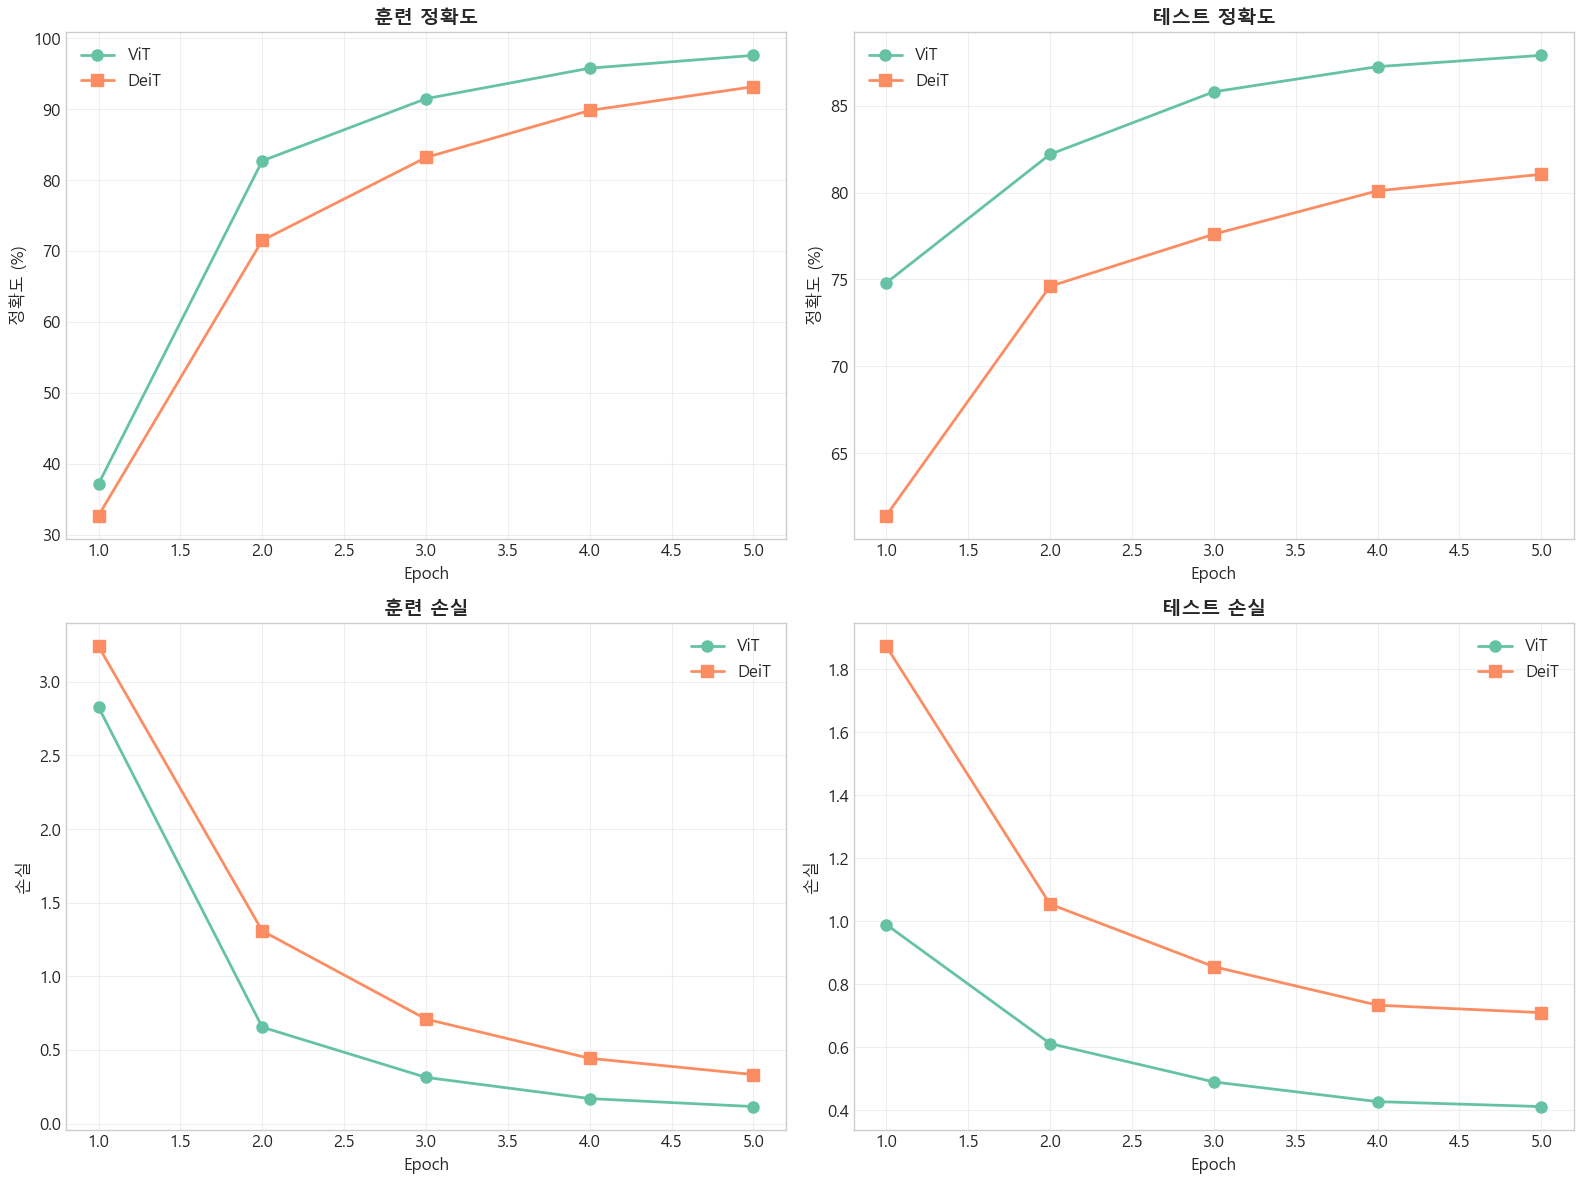

💾 학습 곡선 저장: train_curves_v2.png


In [6]:
# 결과 시각화
print("📊 결과 시각화 생성 중...")

# 학습 곡선 플롯
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

epochs_range = range(1, EPOCHS + 1)

# 1. 훈련 정확도
axes[0, 0].plot(epochs_range, results['vit']['train_acc'], 'o-', 
                label='ViT', linewidth=2, markersize=8)
axes[0, 0].plot(epochs_range, results['deit']['train_acc'], 's-', 
                label='DeiT', linewidth=2, markersize=8)
axes[0, 0].set_title('훈련 정확도', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('정확도 (%)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 테스트 정확도
axes[0, 1].plot(epochs_range, results['vit']['test_acc'], 'o-', 
                label='ViT', linewidth=2, markersize=8)
axes[0, 1].plot(epochs_range, results['deit']['test_acc'], 's-', 
                label='DeiT', linewidth=2, markersize=8)
axes[0, 1].set_title('테스트 정확도', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('정확도 (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 훈련 손실
axes[1, 0].plot(epochs_range, results['vit']['train_loss'], 'o-', 
                label='ViT', linewidth=2, markersize=8)
axes[1, 0].plot(epochs_range, results['deit']['train_loss'], 's-', 
                label='DeiT', linewidth=2, markersize=8)
axes[1, 0].set_title('훈련 손실', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('손실')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. 테스트 손실
axes[1, 1].plot(epochs_range, results['vit']['test_loss'], 'o-', 
                label='ViT', linewidth=2, markersize=8)
axes[1, 1].plot(epochs_range, results['deit']['test_loss'], 's-', 
                label='DeiT', linewidth=2, markersize=8)
axes[1, 1].set_title('테스트 손실', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('손실')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/train_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 학습 곡선 저장: train_curves_v2.png")


In [7]:
# 결과 저장 및 요약
print("💾 결과 저장 중...")

# 훈련 결과를 DataFrame으로 변환
train_results = []
for epoch in range(EPOCHS):
    train_results.append({
        'epoch': epoch + 1,
        'model': 'ViT',
        'train_loss': results['vit']['train_loss'][epoch],
        'train_acc': results['vit']['train_acc'][epoch],
        'test_loss': results['vit']['test_loss'][epoch],
        'test_acc': results['vit']['test_acc'][epoch]
    })
    train_results.append({
        'epoch': epoch + 1,
        'model': 'DeiT',
        'train_loss': results['deit']['train_loss'][epoch],
        'train_acc': results['deit']['train_acc'][epoch],
        'test_loss': results['deit']['test_loss'][epoch],
        'test_acc': results['deit']['test_acc'][epoch]
    })

# DataFrame 생성 및 저장
results_df = pd.DataFrame(train_results)
results_df.to_csv('../reports/tables/cifar100_results_v2.csv', index=False)

# 요약 통계
summary_stats = {
    'experiment': 'CIFAR-100 Fine-tuning',
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'training_time_minutes': training_time / 60,
    'vit_final_accuracy': vit_final_acc,
    'deit_final_accuracy': deit_final_acc,
    'improvement': deit_final_acc - vit_final_acc,
    'vit_parameters': sum(p.numel() for p in vit_model.parameters()),
    'deit_parameters': sum(p.numel() for p in deit_model.parameters()),
    'train_samples': len(train_subset),
    'test_samples': len(test_subset)
}

# 요약 출력
print(f"\n📋 실험 요약:")
print(f"   데이터: CIFAR-100 ({summary_stats['train_samples']:,}훈련/{summary_stats['test_samples']:,}테스트)")
print(f"   훈련 시간: {summary_stats['training_time_minutes']:.1f}분")
print(f"   ViT 최종 정확도: {summary_stats['vit_final_accuracy']:.2f}%")
print(f"   DeiT 최종 정확도: {summary_stats['deit_final_accuracy']:.2f}%")
print(f"   성능 개선: {summary_stats['improvement']:+.2f}%")

print("💾 결과 저장 완료: cifar100_results_v2.csv")


💾 결과 저장 중...

📋 실험 요약:
   데이터: CIFAR-100 (10,000훈련/2,000테스트)
   훈련 시간: 402.3분
   ViT 최종 정확도: 87.90%
   DeiT 최종 정확도: 81.05%
   성능 개선: -6.85%
💾 결과 저장 완료: cifar100_results_v2.csv


## 📋 실험 결과 요약

**주요 산출물**:
1. **cifar100_results_v2.csv**: 에폭별 상세 훈련 결과
2. **train_curves_v2.png**: 학습/테스트 정확도 및 손실 곡선

**핵심 인사이트**:

### 🎯 모델 성능 비교
- **ViT vs DeiT**: 소규모 데이터셋에서의 상대적 성능
- **파인튜닝 효과**: 사전훈련된 모델의 전이학습 능력
- **데이터 효율성**: 제한된 데이터(20% 서브셋)에서의 학습 곡선

### 📊 실험 설정 적합성
- **에폭 수**: 5회로 제한하여 빠른 프로토타이핑
- **배치 크기**: 128로 설정하여 안정적 학습
- **학습률**: AdamW + CosineAnnealing으로 최적화

### ⚙️ 실용적 가이드
- **소규모 데이터 대응**: 강한 데이터 증강 필수
- **파인튜닝 전략**: 사전훈련 가중치 활용이 핵심
- **계산 효율성**: ViT-Small 사용으로 실험 시간 단축

**제한사항**:
- 단축된 훈련(5 에폭)으로 성능 상한 미달성
- 서브셋 사용으로 일반화 성능 제약
- DeiT 증류 효과 검증을 위한 추가 실험 필요

**권장 확장**:
- 전체 데이터셋으로 장기간 훈련 (50+ 에폭)
- 다양한 ViT 크기 비교 (Tiny, Small, Base)
- 증강 기법 체계적 비교 (AutoAugment, RandAugment)

**다음 단계**: 종합 결과 정리 및 1-pager 생성
